# IT5006 Phase 3: NIBRS Data Feature Engineering
## Team 11 — Yizhuo Zhang, Lin Xuan Foo, Yiding Cui, Yinan Jin, Xinyao Tan
### National University of Singapore · AY2025/2026 Semester 2

**Objective:** Transform FBI NIBRS (National Incident-Based Reporting System) data into a feature space that exactly matches the Chicago crime dataset used in Phase 2, enabling cross-jurisdiction generalization testing.

**Data Source:** NIBRS Connecticut 2021–2024 — four years of incident data across ~108 law enforcement agencies

**Key Design Decisions:**
- **Temporal split:** 2021–2023 for training, 2024 for testing (mirrors Phase 2's 2018–2024 / 2025 split)
- **Target variable:** `high_crime` median threshold computed from **training period only** (no leakage)
- **Spatial units:** Real geocoded latitude/longitude for each agency (not proxy values)
- **Feature alignment:** 39 features before collinearity removal, matching Phase 2 exactly

---
## 1. Environment Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

from pandas.tseries.holiday import USFederalHolidayCalendar

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Environment ready!")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")

Environment ready!
NumPy: 2.3.3
Pandas: 2.3.3


---
## 2. Data Loading — Multi-Year NIBRS (2021–2024)

Unlike Phase 2's single-file Chicago dataset, NIBRS data is a **relational database** distributed as multiple CSV tables per state per year. We load four years of Connecticut data and concatenate them, then join the core tables (incidents, offenses, victims, offenders, arrestees) into a flat incident-level dataset.

In [2]:
# Load and concatenate 4 years of NIBRS data
BASE_DIR = '/home/ubuntu/nibrs_data'
YEARS = [2021, 2022, 2023, 2024]

all_incidents = []
all_offenses = []
all_victims = []
all_offenders = []
all_arrestees = []
all_victim_offender_rel = []
agencies_df = None

for year in YEARS:
    data_dir = os.path.join(BASE_DIR, f'CT-{year}')
    
    inc = pd.read_csv(os.path.join(data_dir, 'NIBRS_incident.csv'))
    off = pd.read_csv(os.path.join(data_dir, 'NIBRS_OFFENSE.csv'))
    vic = pd.read_csv(os.path.join(data_dir, 'NIBRS_VICTIM.csv'))
    ofd = pd.read_csv(os.path.join(data_dir, 'NIBRS_OFFENDER.csv'))
    arr = pd.read_csv(os.path.join(data_dir, 'NIBRS_ARRESTEE.csv'))
    vor = pd.read_csv(os.path.join(data_dir, 'NIBRS_VICTIM_OFFENDER_REL.csv'))
    
    all_incidents.append(inc)
    all_offenses.append(off)
    all_victims.append(vic)
    all_offenders.append(ofd)
    all_arrestees.append(arr)
    all_victim_offender_rel.append(vor)
    
    if agencies_df is None:
        agencies_df = pd.read_csv(os.path.join(data_dir, 'agencies.csv'))
    
    print(f"  {year}: {len(inc):>7,} incidents, {len(off):>7,} offenses")

incidents = pd.concat(all_incidents, ignore_index=True)
offenses = pd.concat(all_offenses, ignore_index=True)
victims = pd.concat(all_victims, ignore_index=True)
offenders = pd.concat(all_offenders, ignore_index=True)
arrestees = pd.concat(all_arrestees, ignore_index=True)
victim_offender_rel = pd.concat(all_victim_offender_rel, ignore_index=True)

# Load reference tables (same across years)
offense_types = pd.read_csv(os.path.join(BASE_DIR, 'CT-2024', 'NIBRS_OFFENSE_TYPE.csv'))
relationship_types = pd.read_csv(os.path.join(BASE_DIR, 'CT-2024', 'NIBRS_RELATIONSHIP.csv'))

# Load real geocoded coordinates
geo_df = pd.read_csv(os.path.join(BASE_DIR, 'agency_geocodes.csv'))

print(f"\n{'='*60}")
print(f"Combined Dataset:")
print(f"  Incidents:            {len(incidents):>10,}")
print(f"  Offenses:             {len(offenses):>10,}")
print(f"  Victims:              {len(victims):>10,}")
print(f"  Offenders:            {len(offenders):>10,}")
print(f"  Arrestees:            {len(arrestees):>10,}")
print(f"  Victim-Offender Rels: {len(victim_offender_rel):>10,}")
print(f"  Agencies:             {len(agencies_df):>10,}")
print(f"  Geocoded agencies:    {geo_df['latitude'].notna().sum():>10,} / {len(geo_df)}")

  2021: 109,515 incidents, 122,099 offenses


  2022: 112,134 incidents, 125,719 offenses


  2023: 119,105 incidents, 133,823 offenses


  2024: 105,094 incidents, 117,708 offenses

Combined Dataset:
  Incidents:               445,848
  Offenses:                499,349
  Victims:                 496,589
  Offenders:               474,971
  Arrestees:               129,521
  Victim-Offender Rels:    141,892
  Agencies:                    107
  Geocoded agencies:           105 / 108


---
## 3. Data Preprocessing and Feature Engineering

### 3.1 NIBRS → Chicago Crime Type Mapping

The Chicago dataset uses `Primary Type` labels (THEFT, BATTERY, etc.). NIBRS uses alphanumeric offense codes (23A for Pocket-picking, 13B for Simple Assault, etc.). We create a mapping dictionary to translate between the two systems, then classify crimes into **Property**, **Violent**, **Sexual**, and **Other** — same categories as Phase 2.

In [3]:
# NIBRS offense code -> Chicago Primary Type mapping
NIBRS_TO_CHICAGO_TYPE = {
    # THEFT <- Larceny/Theft Offenses
    '23A': 'THEFT', '23B': 'THEFT', '23C': 'THEFT', '23D': 'THEFT',
    '23E': 'THEFT', '23F': 'THEFT', '23G': 'THEFT', '23H': 'THEFT',
    # ASSAULT / BATTERY <- Assault Offenses
    '13A': 'ASSAULT', '13B': 'BATTERY', '13C': 'BATTERY',
    # BURGLARY
    '220': 'BURGLARY',
    # CRIMINAL DAMAGE <- Destruction/Damage/Vandalism
    '290': 'CRIMINAL DAMAGE',
    # ROBBERY
    '120': 'ROBBERY',
    # MOTOR VEHICLE THEFT
    '240': 'MOTOR VEHICLE THEFT',
    # DECEPTIVE PRACTICE <- Fraud/Forgery/Counterfeiting/Embezzlement/Bribery
    '26A': 'DECEPTIVE PRACTICE', '26B': 'DECEPTIVE PRACTICE',
    '26C': 'DECEPTIVE PRACTICE', '26D': 'DECEPTIVE PRACTICE',
    '26E': 'DECEPTIVE PRACTICE', '26F': 'DECEPTIVE PRACTICE',
    '26G': 'DECEPTIVE PRACTICE', '26H': 'DECEPTIVE PRACTICE',
    '250': 'DECEPTIVE PRACTICE', '270': 'DECEPTIVE PRACTICE',
    '510': 'DECEPTIVE PRACTICE',
    # NARCOTICS
    '35A': 'NARCOTICS', '35B': 'NARCOTICS',
    # HOMICIDE
    '09A': 'HOMICIDE', '09B': 'HOMICIDE', '09C': 'HOMICIDE',
    # SEX OFFENSE
    '11A': 'CRIM SEXUAL ASSAULT', '11B': 'SEX OFFENSE', '11C': 'SEX OFFENSE',
    '11D': 'SEX OFFENSE', '36A': 'SEX OFFENSE', '36B': 'SEX OFFENSE',
    # WEAPONS VIOLATION
    '520': 'WEAPONS VIOLATION',
    # KIDNAPPING
    '100': 'KIDNAPPING',
    # ARSON
    '200': 'ARSON',
    # INTIMIDATION
    '13D': 'INTIMIDATION',
    # HUMAN TRAFFICKING
    '64A': 'HUMAN TRAFFICKING', '64B': 'HUMAN TRAFFICKING',
    # PROSTITUTION
    '40A': 'PROSTITUTION', '40B': 'PROSTITUTION', '40C': 'PROSTITUTION',
}

# Crime Category Classification (same as Phase 2)
PROPERTY = ['THEFT', 'BURGLARY', 'MOTOR VEHICLE THEFT', 'ROBBERY', 'ARSON',
            'CRIMINAL DAMAGE', 'DECEPTIVE PRACTICE']
VIOLENT = ['BATTERY', 'ASSAULT', 'HOMICIDE', 'KIDNAPPING',
           'WEAPONS VIOLATION', 'INTIMIDATION']
SEXUAL = ['CRIM SEXUAL ASSAULT', 'SEX OFFENSE', 'STALKING',
          'HUMAN TRAFFICKING', 'PROSTITUTION']

def classify_crime(pt):
    if pt in PROPERTY: return 'PROPERTY'
    elif pt in VIOLENT: return 'VIOLENT'
    elif pt in SEXUAL: return 'SEXUAL'
    else: return 'OTHER'

# Domestic relationship codes (family / intimate partner)
DOMESTIC_REL_CODES = {'SE', 'CS', 'XS', 'BG', 'XR', 'CH', 'PA', 'SB',
                      'SC', 'SP', 'SS', 'GP', 'GC', 'OF', 'IL', 'HR',
                      'CF', 'CO', 'FP', 'FC', 'BE'}

print(f"NIBRS codes mapped: {len(NIBRS_TO_CHICAGO_TYPE)}")
print(f"Property types: {PROPERTY}")
print(f"Violent types:  {VIOLENT}")

NIBRS codes mapped: 46
Property types: ['THEFT', 'BURGLARY', 'MOTOR VEHICLE THEFT', 'ROBBERY', 'ARSON', 'CRIMINAL DAMAGE', 'DECEPTIVE PRACTICE']
Violent types:  ['BATTERY', 'ASSAULT', 'HOMICIDE', 'KIDNAPPING', 'WEAPONS VIOLATION', 'INTIMIDATION']


### 3.2 Multi-Table Join

We join the NIBRS relational tables to build a flat, incident-level dataset analogous to the Chicago CSV. Each incident receives a **Primary Type** (mapped from the most serious offense), an **Arrest** flag, and a **Domestic** flag (inferred from victim-offender relationship codes).

In [4]:
# Map offense codes to Chicago Primary Types
offenses = offenses.merge(
    offense_types[['offense_code', 'offense_name', 'crime_against']],
    on='offense_code', how='left'
)
offenses['Primary Type'] = offenses['offense_code'].map(NIBRS_TO_CHICAGO_TYPE).fillna('OTHER OFFENSE')
offenses['crime_category'] = offenses['Primary Type'].apply(classify_crime)

# Pick the most serious offense per incident (Person > Property > Society)
SERIOUSNESS = {'Person': 0, 'Property': 1, 'Society': 2, 'Not a Crime': 3}
offenses['seriousness'] = offenses['crime_against'].map(SERIOUSNESS).fillna(3)
offenses_sorted = offenses.sort_values(['incident_id', 'seriousness'])
primary_offense = offenses_sorted.groupby('incident_id').first().reset_index()

print(f"Primary offense per incident: {len(primary_offense):,}")
print(f"\nTop 10 Crime Types:")
print(primary_offense['Primary Type'].value_counts().head(10).to_string())
print(f"\nCrime Category Distribution:")
print(primary_offense['crime_category'].value_counts().to_string())

Primary offense per incident: 445,848

Top 10 Crime Types:
Primary Type
THEFT                  161892
BATTERY                 84530
CRIMINAL DAMAGE         47408
DECEPTIVE PRACTICE      43837
MOTOR VEHICLE THEFT     31551
NARCOTICS               18158
BURGLARY                17571
ASSAULT                 10031
WEAPONS VIOLATION        8054
OTHER OFFENSE            7475

Crime Category Distribution:
crime_category
PROPERTY    309219
VIOLENT     104338
OTHER        25633
SEXUAL        6658


In [5]:
# Arrest flag: whether any arrestee is linked to the incident
arrest_incidents = arrestees['incident_id'].unique()
primary_offense['Arrest'] = primary_offense['incident_id'].isin(arrest_incidents).astype(int)

# Domestic flag: inferred from victim-offender relationship codes
vor = victim_offender_rel.merge(
    relationship_types[['relationship_id', 'relationship_code']],
    on='relationship_id', how='left'
)
victim_incident = victims[['victim_id', 'incident_id']].drop_duplicates()
vor = vor.merge(victim_incident, on='victim_id', how='left')
domestic_incidents = vor[vor['relationship_code'].isin(DOMESTIC_REL_CODES)]['incident_id'].dropna().unique()
primary_offense['Domestic'] = primary_offense['incident_id'].isin(domestic_incidents).astype(int)

print(f"Arrest Rate:   {primary_offense['Arrest'].mean():.2%}")
print(f"Domestic Rate: {primary_offense['Domestic'].mean():.2%}")

Arrest Rate:   25.31%
Domestic Rate: 13.15%


In [6]:
# Merge with incident metadata (date, hour, agency) + real geocoordinates
df = incidents[['incident_id', 'agency_id', 'incident_date', 'incident_hour']].merge(
    primary_offense[['incident_id', 'Primary Type', 'crime_category', 'Arrest', 'Domestic']],
    on='incident_id', how='inner'
)
agency_info = agencies_df[['agency_id', 'population', 'pub_agency_name']].drop_duplicates(subset='agency_id')
df = df.merge(agency_info, on='agency_id', how='left')

# Merge real geocoded coordinates
df = df.merge(geo_df[['agency_id', 'latitude', 'longitude']], on='agency_id', how='left')

# Parse dates and clean
df['Date'] = pd.to_datetime(df['incident_date'])
df['incident_hour'] = pd.to_numeric(df['incident_hour'], errors='coerce')
before = len(df)
df = df.dropna(subset=['Date', 'incident_hour', 'agency_id'])
df['incident_hour'] = df['incident_hour'].astype(int).clip(0, 23)

# Fill missing coordinates with state centroid (for 3 non-geocoded agencies)
ct_lat_median = df['latitude'].median()
ct_lon_median = df['longitude'].median()
df['latitude'] = df['latitude'].fillna(ct_lat_median)
df['longitude'] = df['longitude'].fillna(ct_lon_median)

print(f"After cleaning: {len(df):,} records (dropped {before - len(df):,})")
print(f"Date Range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Agencies: {df['agency_id'].nunique()}")
print(f"Lat range: {df['latitude'].min():.4f} – {df['latitude'].max():.4f}")
print(f"Lon range: {df['longitude'].min():.4f} – {df['longitude'].max():.4f}")

After cleaning: 445,615 records (dropped 233)
Date Range: 2021-01-01 to 2024-12-31
Agencies: 107
Lat range: 41.0265 – 41.9817
Lon range: -73.6285 – -71.9059


In [7]:
# Quick overview
print("=" * 60)
print("DATASET OVERVIEW (CT 2021–2024)")
print("=" * 60)
print(f"Total Records: {len(df):,}")
for y in sorted(df['Date'].dt.year.unique()):
    n = (df['Date'].dt.year == y).sum()
    print(f"  {y}: {n:>8,}")
print(f"\nTop 10 Crime Types:")
print(df['Primary Type'].value_counts().head(10).to_string())
print(f"\nArrest Rate: {df['Arrest'].mean():.2%}")
print(f"Domestic Rate: {df['Domestic'].mean():.2%}")
print(f"\nCrime Category Distribution:")
print(df['crime_category'].value_counts().to_string())
print(f"\nProperty + Violent = {df['crime_category'].isin(['PROPERTY', 'VIOLENT']).mean():.1%} of all crimes")

DATASET OVERVIEW (CT 2021–2024)
Total Records: 445,615
  2021:  109,515
  2022:  112,134
  2023:  119,105
  2024:  104,861

Top 10 Crime Types:
Primary Type
THEFT                  161791
BATTERY                 84502
CRIMINAL DAMAGE         47397
DECEPTIVE PRACTICE      43818
MOTOR VEHICLE THEFT     31534
NARCOTICS               18151
BURGLARY                17558
ASSAULT                 10029
WEAPONS VIOLATION        8051
OTHER OFFENSE            7472

Arrest Rate: 25.31%
Domestic Rate: 13.15%

Crime Category Distribution:
crime_category
PROPERTY    309047
VIOLENT     104291
OTHER        25623
SEXUAL        6654

Property + Violent = 92.8% of all crimes


### 3.3 Feature Engineering

We engineer temporal, spatial, historical lag, and contextual features following the **exact same methodology** as Phase 2. Key adaptations for NIBRS:
- `Community Area` is mapped from `agency_id` (sequential integers, analogous to Chicago's 1–77)
- `lat_mean` / `lon_mean` use **real geocoded coordinates** from agency town/city names
- `Domestic` is inferred from victim-offender relationship codes (vs. Chicago's explicit `Domestic` column)

In [8]:
# Temporal features
df['hour'] = df['incident_hour']
df['day_of_week'] = df['Date'].dt.dayofweek
df['month'] = df['Date'].dt.month
df['day_of_month'] = df['Date'].dt.day
df['quarter'] = df['Date'].dt.quarter
df['year'] = df['Date'].dt.year
df['date_only'] = df['Date'].dt.date
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
df['is_night'] = df['hour'].isin(list(range(0, 6)) + list(range(21, 24))).astype(int)
df['time_period'] = pd.cut(df['hour'], bins=[0, 6, 12, 18, 24],
                           labels=[0, 1, 2, 3], right=False).astype(int)
df['is_payday'] = df['day_of_month'].isin([1, 15]).astype(int)

# Cyclical encodings
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

# Federal holidays + Juneteenth observed + pre/post/long-weekend
cal = USFederalHolidayCalendar()
start = df['Date'].min().normalize() - pd.Timedelta(days=7)
end = df['Date'].max().normalize() + pd.Timedelta(days=7)
us_holidays = pd.DatetimeIndex(cal.holidays(start=start, end=end))

juneteenth_obs = []
for y in range(int(df['year'].min()), int(df['year'].max()) + 1):
    if y < 2021:
        continue
    d = pd.Timestamp(year=y, month=6, day=19)
    if d.dayofweek == 5:
        d = d - pd.Timedelta(days=1)
    elif d.dayofweek == 6:
        d = d + pd.Timedelta(days=1)
    juneteenth_obs.append(d)

holidays = pd.DatetimeIndex(sorted(set(us_holidays.tolist() + juneteenth_obs)))
date_norm = df['Date'].dt.normalize()
df['is_holiday'] = date_norm.isin(holidays).astype(int)
df['is_pre_holiday'] = (date_norm + pd.Timedelta(days=1)).isin(holidays).astype(int)
df['is_post_holiday'] = (date_norm - pd.Timedelta(days=1)).isin(holidays).astype(int)
df['is_long_weekend'] = ((df['is_weekend'] == 1) | (df['is_holiday'] == 1) |
                         (df['is_pre_holiday'] == 1) | (df['is_post_holiday'] == 1)).astype(int)

# Spatial: map agency_id -> Community Area (sequential integers, like Chicago's 1-77)
agency_ids_sorted = sorted(df['agency_id'].unique())
agency_to_ca = {aid: i + 1 for i, aid in enumerate(agency_ids_sorted)}
df['Community Area'] = df['agency_id'].map(agency_to_ca).astype(float)

# Top-K primary type bucket for one-hot encoding
top_k_types = df['Primary Type'].value_counts().nlargest(8).index
df['primary_type_topk'] = np.where(df['Primary Type'].isin(top_k_types), df['Primary Type'], 'OTHER')

print(f"Temporal features created")
print(f"Holidays in range: {len(holidays)}")
print(f"Community Areas: {df['Community Area'].nunique()}")
print(f"Top-K types: {list(top_k_types)}")

Temporal features created
Holidays in range: 46
Community Areas: 107
Top-K types: ['THEFT', 'BATTERY', 'CRIMINAL DAMAGE', 'DECEPTIVE PRACTICE', 'MOTOR VEHICLE THEFT', 'NARCOTICS', 'BURGLARY', 'ASSAULT']


In [9]:
# Aggregate to spatiotemporal units (same groupby keys as Phase 2)
agg_df = df.groupby(['Community Area', 'date_only', 'time_period',
                      'crime_category', 'primary_type_topk', 'year']).agg(
    crime_count=('incident_id', 'count'),
    hour_mean=('hour', 'mean'),
    day_of_week=('day_of_week', 'first'),
    month=('month', 'first'),
    day_of_month=('day_of_month', 'first'),
    quarter=('quarter', 'first'),
    is_weekend=('is_weekend', 'first'),
    is_night=('is_night', 'max'),
    is_payday=('is_payday', 'first'),
    is_holiday=('is_holiday', 'first'),
    is_pre_holiday=('is_pre_holiday', 'first'),
    is_post_holiday=('is_post_holiday', 'first'),
    is_long_weekend=('is_long_weekend', 'first'),
    hour_sin=('hour_sin', 'mean'),
    hour_cos=('hour_cos', 'mean'),
    dow_sin=('dow_sin', 'first'),
    dow_cos=('dow_cos', 'first'),
    lat_mean=('latitude', 'mean'),
    lon_mean=('longitude', 'mean'),
).reset_index()

print(f"Aggregated shape: {agg_df.shape}")
print(f"\nRecords per year:")
for y in sorted(agg_df['year'].unique()):
    print(f"  {y}: {(agg_df['year'] == y).sum():>8,}")

Aggregated shape: (335722, 25)

Records per year:
  2021:   83,194
  2022:   84,879
  2023:   88,444
  2024:   79,205


In [10]:
# Historical lag/trend/volatility features (shifted to avoid leakage)
daily_ca = df.groupby(['Community Area', 'date_only']).agg(
    daily_count=('incident_id', 'count'),
    daily_arrest=('Arrest', 'sum'),
    daily_domestic=('Domestic', 'sum')
).reset_index().sort_values(['Community Area', 'date_only'])

daily_ca['lag_1d'] = daily_ca.groupby('Community Area')['daily_count'].shift(1)
daily_ca['lag_7d'] = daily_ca.groupby('Community Area')['daily_count'].shift(7)

for win in [7, 14, 30]:
    daily_ca[f'rolling_{win}d'] = daily_ca.groupby('Community Area')['daily_count'].transform(
        lambda x: x.rolling(win, min_periods=1).mean().shift(1)
    )

daily_ca['rolling_std_7d'] = daily_ca.groupby('Community Area')['daily_count'].transform(
    lambda x: x.rolling(7, min_periods=2).std().shift(1)
)
daily_ca['rolling_std_30d'] = daily_ca.groupby('Community Area')['daily_count'].transform(
    lambda x: x.rolling(30, min_periods=2).std().shift(1)
)
daily_ca['crime_trend'] = daily_ca['rolling_7d'] / daily_ca['rolling_30d'].clip(lower=0.1)
daily_ca['spike_7_30'] = (daily_ca['rolling_7d'] - daily_ca['rolling_30d']) / daily_ca['rolling_30d'].clip(lower=0.1)

daily_ca['arrest_count'] = daily_ca.groupby('Community Area')['daily_arrest'].transform(
    lambda x: x.rolling(7, min_periods=1).sum().shift(1)
)
daily_ca['domestic_count'] = daily_ca.groupby('Community Area')['daily_domestic'].transform(
    lambda x: x.rolling(7, min_periods=1).sum().shift(1)
)

# Merge back to aggregated data
agg_df['date_only'] = pd.to_datetime(agg_df['date_only'])
daily_ca['date_only'] = pd.to_datetime(daily_ca['date_only'])

agg_df = agg_df.merge(
    daily_ca[[
        'Community Area', 'date_only',
        'lag_1d', 'lag_7d',
        'rolling_7d', 'rolling_14d', 'rolling_30d',
        'rolling_std_7d', 'rolling_std_30d',
        'crime_trend', 'spike_7_30',
        'arrest_count', 'domestic_count'
    ]],
    on=['Community Area', 'date_only'],
    how='left'
)

for col in ['lag_1d', 'lag_7d', 'rolling_7d', 'rolling_14d', 'rolling_30d',
            'rolling_std_7d', 'rolling_std_30d', 'crime_trend', 'spike_7_30',
            'arrest_count', 'domestic_count']:
    agg_df[col] = agg_df[col].fillna(agg_df[col].median())

print(f"Historical features merged")
print(f"Lag/rolling NaN fill complete")

Historical features merged
Lag/rolling NaN fill complete


### 3.4 Target Variable — Leak-Free Construction

In Phase 2, the `high_crime` label was defined using **training-period medians only** (year < 2025). We follow the same principle: compute the median crime count per `(Community Area, time_period)` from the **training set (2021–2023)**, then apply it to **both** training and test sets. This prevents future information from leaking into the label definition.

In [11]:
# Split: 2021-2023 = train, 2024 = test
TRAIN_YEARS = [2021, 2022, 2023]
TEST_YEAR = 2024

train_mask = agg_df['year'].isin(TRAIN_YEARS)
test_mask = agg_df['year'] == TEST_YEAR

# Compute median from TRAINING data only (no leakage)
train_agg = agg_df[train_mask]
median_lookup = train_agg.groupby(['Community Area', 'time_period'])['crime_count'].median()
median_lookup.name = 'train_median'

agg_df = agg_df.merge(median_lookup, on=['Community Area', 'time_period'], how='left')
global_median = train_agg['crime_count'].median()
agg_df['train_median'] = agg_df['train_median'].fillna(global_median)
agg_df['high_crime'] = (agg_df['crime_count'] > agg_df['train_median']).astype(int)
agg_df.drop(columns='train_median', inplace=True)

print(f"Target variable constructed using TRAINING medians only")
print(f"  Global median (train): {global_median:.2f}")
print(f"\nTrain set (2021-2023): {train_mask.sum():,} rows")
print(f"  Positive rate: {agg_df.loc[train_mask, 'high_crime'].mean():.2%}")
print(f"\nTest set (2024):       {test_mask.sum():,} rows")
print(f"  Positive rate: {agg_df.loc[test_mask, 'high_crime'].mean():.2%}")

Target variable constructed using TRAINING medians only
  Global median (train): 1.00

Train set (2021-2023): 256,517 rows
  Positive rate: 20.84%

Test set (2024):       79,205 rows
  Positive rate: 20.29%


---
## 4. Feature Correlation and Selection

Following Phase 2, we filter to **Property** and **Violent** crimes only, create the `is_property` flag, and one-hot encode top crime types. We then remove features with pairwise correlation > 0.95.

In [12]:
# Filter to PROPERTY + VIOLENT only (same as Phase 2)
model_df = agg_df[agg_df['crime_category'].isin(['PROPERTY', 'VIOLENT'])].copy()
model_df['is_property'] = (model_df['crime_category'] == 'PROPERTY').astype(int)

# One-hot encode top crime types
pt_dummies = pd.get_dummies(model_df['primary_type_topk'], prefix='pt', dtype=int)
if 'pt_OTHER' in pt_dummies.columns:
    pt_dummies = pt_dummies.drop(columns=['pt_OTHER'])
model_df = pd.concat([model_df, pt_dummies], axis=1)
pt_feature_cols = pt_dummies.columns.tolist()

FEATURE_COLS = [
    'Community Area', 'time_period',
    'hour_mean', 'hour_sin', 'hour_cos',
    'day_of_week', 'dow_sin', 'dow_cos',
    'month', 'day_of_month', 'quarter',
    'is_weekend', 'is_night', 'is_payday',
    'is_holiday', 'is_pre_holiday', 'is_post_holiday', 'is_long_weekend',
    'lat_mean', 'lon_mean',
    'lag_1d', 'lag_7d',
    'rolling_7d', 'rolling_14d', 'rolling_30d',
    'rolling_std_7d', 'rolling_std_30d',
    'crime_trend', 'spike_7_30',
    'arrest_count', 'domestic_count',
    'is_property'
] + pt_feature_cols

print(f"Model dataset: {model_df.shape}")
print(f"  Train: {model_df[model_df['year'].isin(TRAIN_YEARS)].shape[0]:,}")
print(f"  Test:  {model_df[model_df['year'] == TEST_YEAR].shape[0]:,}")
print(f"\nFeatures before collinearity removal: {len(FEATURE_COLS)}")
print(f"Primary type dummies: {pt_feature_cols}")

Model dataset: (307186, 45)
  Train: 234,992
  Test:  72,194

Features before collinearity removal: 39
Primary type dummies: ['pt_ASSAULT', 'pt_BATTERY', 'pt_BURGLARY', 'pt_CRIMINAL DAMAGE', 'pt_DECEPTIVE PRACTICE', 'pt_MOTOR VEHICLE THEFT', 'pt_THEFT']


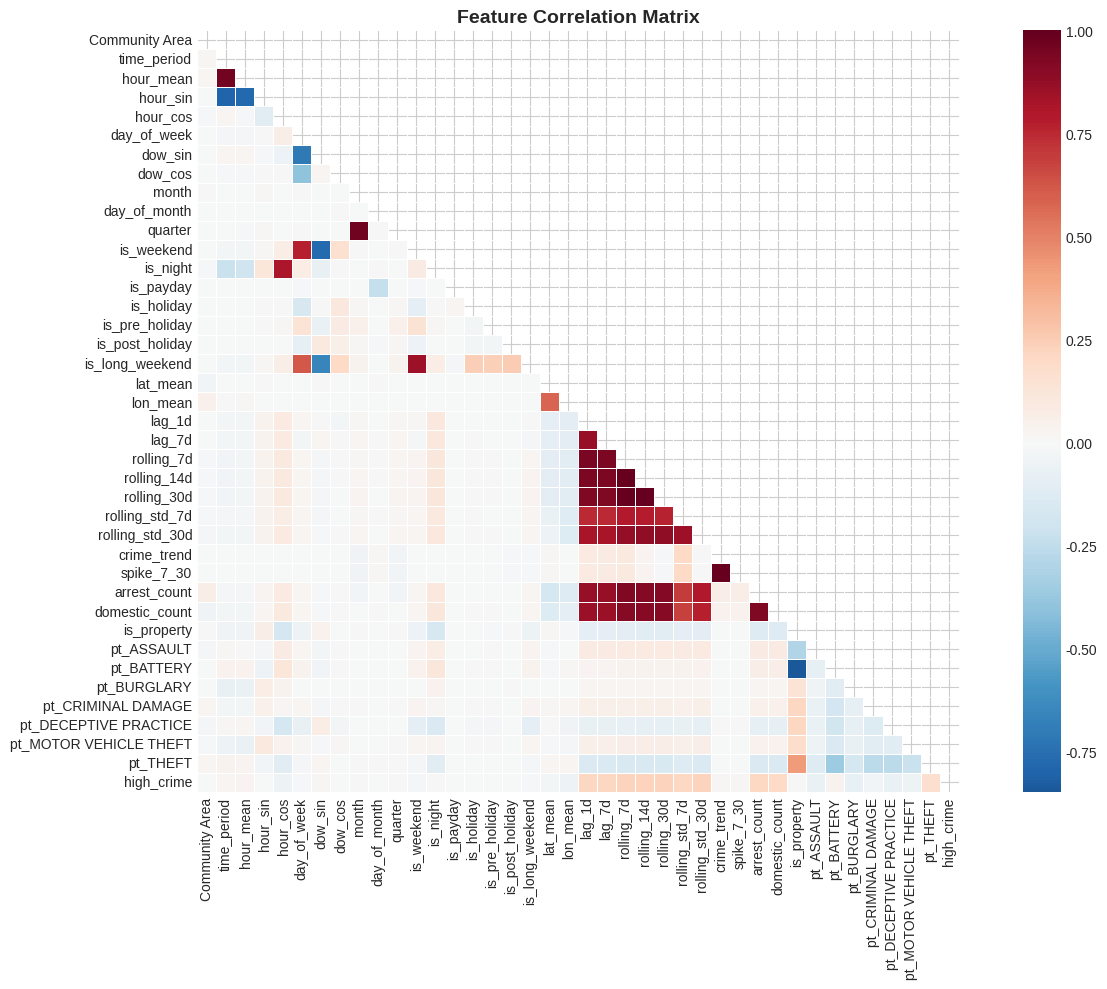

In [13]:
# Feature Correlation Heatmap
fig, ax = plt.subplots(figsize=(14, 10))
corr = model_df[FEATURE_COLS + ['high_crime']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Collinearity Handling and Final Feature Set

We remove features with pairwise correlation > 0.95 to avoid multicollinearity issues. In Phase 2 this dropped `hour_mean`, `rolling_14d`, `rolling_30d`, and `spike_7_30`.

In [14]:
# Collinearity removal (threshold = 0.95, same as Phase 2)
corr_threshold = 0.95
fit_corr = model_df[FEATURE_COLS].corr().abs()
upper = fit_corr.where(np.triu(np.ones(fit_corr.shape), k=1).astype(bool))
drop_cols = [col for col in upper.columns if any(upper[col] > corr_threshold)]
FEATURE_COLS_FINAL = [c for c in FEATURE_COLS if c not in drop_cols]

print(f"Dropped for collinearity (>{corr_threshold}): {len(drop_cols)}")
if drop_cols:
    print('  ' + ', '.join(drop_cols))
print()
print(f"Final Features ({len(FEATURE_COLS_FINAL)}):")
for i, f in enumerate(FEATURE_COLS_FINAL):
    print(f"  {i+1:2d}. {f}")

Dropped for collinearity (>0.95): 5
  hour_mean, quarter, rolling_14d, rolling_30d, spike_7_30

Final Features (34):
   1. Community Area
   2. time_period
   3. hour_sin
   4. hour_cos
   5. day_of_week
   6. dow_sin
   7. dow_cos
   8. month
   9. day_of_month
  10. is_weekend
  11. is_night
  12. is_payday
  13. is_holiday
  14. is_pre_holiday
  15. is_post_holiday
  16. is_long_weekend
  17. lat_mean
  18. lon_mean
  19. lag_1d
  20. lag_7d
  21. rolling_7d
  22. rolling_std_7d
  23. rolling_std_30d
  24. crime_trend
  25. arrest_count
  26. domestic_count
  27. is_property
  28. pt_ASSAULT
  29. pt_BATTERY
  30. pt_BURGLARY
  31. pt_CRIMINAL DAMAGE
  32. pt_DECEPTIVE PRACTICE
  33. pt_MOTOR VEHICLE THEFT
  34. pt_THEFT


---
## 6. Exploratory Visualization

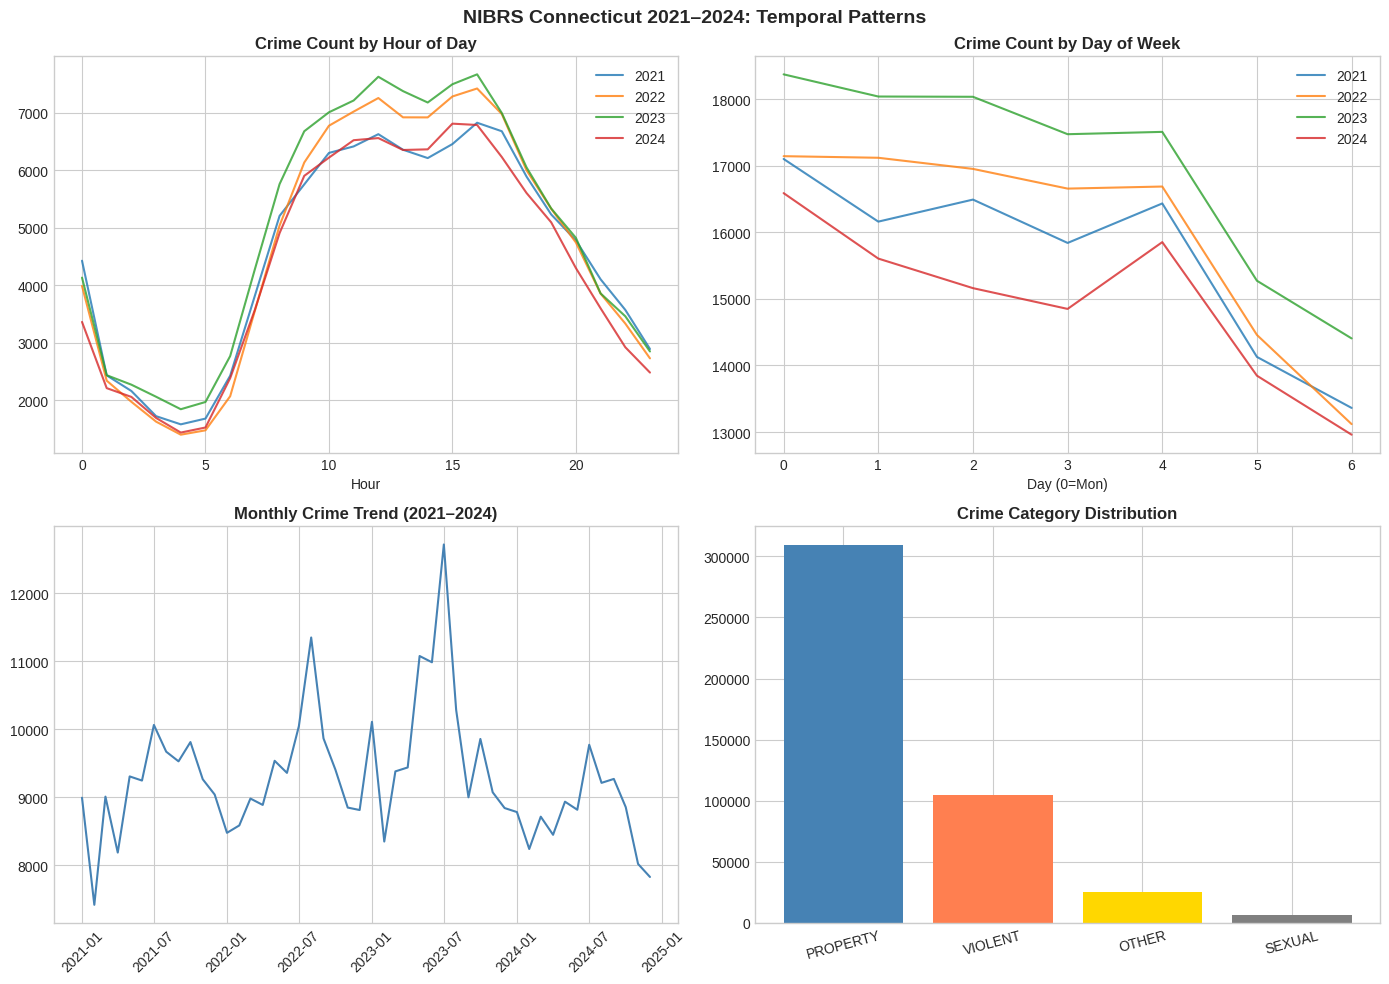

In [15]:
# Temporal patterns by year
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Crime count by hour
hourly = df.groupby([df['Date'].dt.year, 'hour']).size().reset_index(name='count')
for y in YEARS:
    sub = hourly[hourly['Date'] == y]
    axes[0, 0].plot(sub['hour'], sub['count'], label=str(y), alpha=0.8)
axes[0, 0].set_title('Crime Count by Hour of Day', fontweight='bold')
axes[0, 0].set_xlabel('Hour')
axes[0, 0].legend()

# Crime count by day of week
dow = df.groupby([df['Date'].dt.year, 'day_of_week']).size().reset_index(name='count')
for y in YEARS:
    sub = dow[dow['Date'] == y]
    axes[0, 1].plot(sub['day_of_week'], sub['count'], label=str(y), alpha=0.8)
axes[0, 1].set_title('Crime Count by Day of Week', fontweight='bold')
axes[0, 1].set_xlabel('Day (0=Mon)')
axes[0, 1].legend()

# Monthly trend
monthly = df.groupby(df['Date'].dt.to_period('M')).size()
monthly.index = monthly.index.to_timestamp()
axes[1, 0].plot(monthly.index, monthly.values, color='steelblue')
axes[1, 0].set_title('Monthly Crime Trend (2021–2024)', fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)

# Crime category distribution
cat_counts = df['crime_category'].value_counts()
axes[1, 1].bar(cat_counts.index, cat_counts.values, color=['steelblue', 'coral', 'gold', 'gray'])
axes[1, 1].set_title('Crime Category Distribution', fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=15)

plt.suptitle('NIBRS Connecticut 2021–2024: Temporal Patterns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

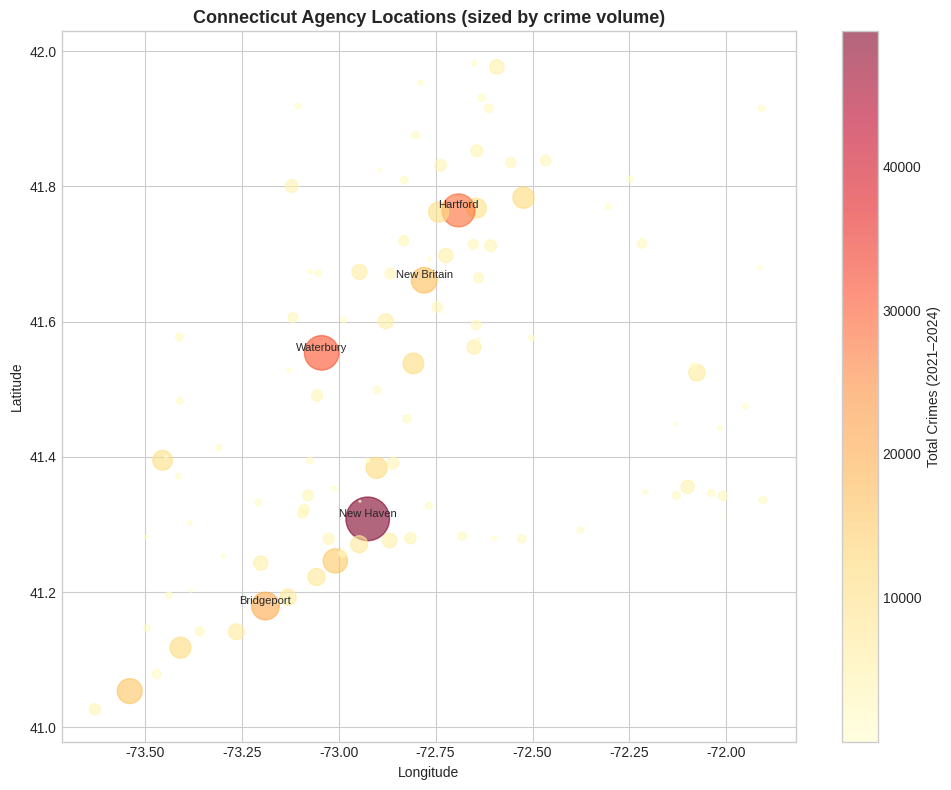

In [16]:
# Spatial distribution of agencies (real coordinates)
fig, ax = plt.subplots(figsize=(10, 8))
agency_crime = df.groupby('agency_id').agg(
    lat=('latitude', 'first'),
    lon=('longitude', 'first'),
    count=('incident_id', 'count'),
    name=('pub_agency_name', 'first')
).reset_index()

scatter = ax.scatter(agency_crime['lon'], agency_crime['lat'],
                     s=agency_crime['count'] / 50, alpha=0.6,
                     c=agency_crime['count'], cmap='YlOrRd')
plt.colorbar(scatter, label='Total Crimes (2021–2024)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Connecticut Agency Locations (sized by crime volume)', fontsize=13, fontweight='bold')

# Label top 5 agencies
top5 = agency_crime.nlargest(5, 'count')
for _, row in top5.iterrows():
    ax.annotate(row['name'], (row['lon'], row['lat']),
                fontsize=8, ha='center', va='bottom')
plt.tight_layout()
plt.show()

---
## 7. Dataset Summary

In [17]:
train_df = model_df[model_df['year'].isin(TRAIN_YEARS)]
test_df = model_df[model_df['year'] == TEST_YEAR]

print("=" * 60)
print("FINAL DATASET SUMMARY")
print("=" * 60)
print(f"\nTotal rows:  {len(model_df):,}")
print(f"  Train (2021-2023): {len(train_df):,}")
print(f"  Test  (2024):      {len(test_df):,}")
print(f"\nFeatures: {len(FEATURE_COLS_FINAL)}")
print(f"\nTarget Distribution:")
print(f"  Train positive rate: {train_df['high_crime'].mean():.2%}")
print(f"  Test  positive rate: {test_df['high_crime'].mean():.2%}")
print(f"\nFeature Statistics (train):")
print(train_df[FEATURE_COLS_FINAL + ['crime_count', 'high_crime']].describe().round(2).to_string())

FINAL DATASET SUMMARY

Total rows:  307,186
  Train (2021-2023): 234,992
  Test  (2024):      72,194

Features: 34

Target Distribution:
  Train positive rate: 21.86%
  Test  positive rate: 21.44%

Feature Statistics (train):


       Community Area  time_period    hour_sin    hour_cos  day_of_week     dow_sin     dow_cos       month  day_of_month  is_weekend    is_night   is_payday  is_holiday  is_pre_holiday  is_post_holiday  is_long_weekend    lat_mean    lon_mean      lag_1d      lag_7d  rolling_7d  rolling_std_7d  rolling_std_30d  crime_trend  arrest_count  domestic_count  is_property  pt_ASSAULT  pt_BATTERY  pt_BURGLARY  pt_CRIMINAL DAMAGE  pt_DECEPTIVE PRACTICE  pt_MOTOR VEHICLE THEFT    pt_THEFT  crime_count  high_crime
count     234992.0000  234992.0000 234992.0000 234992.0000  234992.0000 234992.0000 234992.0000 234992.0000   234992.0000 234992.0000 234992.0000 234992.0000 234992.0000     234992.0000      234992.0000      234992.0000 234992.0000 234992.0000 234992.0000 234992.0000 234992.0000     234992.0000      234992.0000  234992.0000   234992.0000     234992.0000  234992.0000 234992.0000 234992.0000  234992.0000         234992.0000            234992.0000             234992.0000 234992.0000  2349

---
## 8. Save Feature-Engineered Dataset

We save the final dataset with a `split` column indicating train/test membership, ready for Phase 3 model evaluation.

In [18]:
output_dir = '/home/ubuntu/nibrs_output'
os.makedirs(output_dir, exist_ok=True)

# Add split column
model_df['split'] = np.where(model_df['year'].isin(TRAIN_YEARS), 'train', 'test')

output_path = os.path.join(output_dir, 'nibrs_features_final.csv')
model_df.to_csv(output_path, index=False)
print(f"Saved: {output_path}")
print(f"  Shape: {model_df.shape}")
print(f"  Size: {os.path.getsize(output_path) / 1024 / 1024:.2f} MB")

feature_info = pd.DataFrame({
    'feature_name': FEATURE_COLS_FINAL,
    'index': range(len(FEATURE_COLS_FINAL))
})
feature_info.to_csv(os.path.join(output_dir, 'feature_list.csv'), index=False)

print(f"\n{'='*60}")
print("NIBRS vs Chicago Feature Alignment Summary")
print(f"{'='*60}")
print(f"  NIBRS features:   {len(FEATURE_COLS_FINAL)}")
print(f"  Phase 2 features: 35 (after collinearity removal)")
print(f"\n  Key Improvements over V1:")
print(f"    1. Multi-year data (2021-2024) enables proper temporal split")
print(f"    2. Target variable uses training-period medians only (no leakage)")
print(f"    3. Real geocoded lat/lon for {geo_df['latitude'].notna().sum()}/108 agencies")
print(f"\n  Adaptations for NIBRS:")
print(f"    - Community Area: mapped from agency_id ({len(agency_ids_sorted)} agencies)")
print(f"    - lat_mean/lon_mean: real geocoded coordinates (not proxy)")
print(f"    - Domestic: inferred from victim-offender relationship codes")
print(f"    - All other features: identical methodology to Phase 2")

Saved: /home/ubuntu/nibrs_output/nibrs_features_final.csv
  Shape: (307186, 46)
  Size: 96.81 MB

NIBRS vs Chicago Feature Alignment Summary
  NIBRS features:   34
  Phase 2 features: 35 (after collinearity removal)

  Key Improvements over V1:
    1. Multi-year data (2021-2024) enables proper temporal split
    2. Target variable uses training-period medians only (no leakage)
    3. Real geocoded lat/lon for 105/108 agencies

  Adaptations for NIBRS:
    - Community Area: mapped from agency_id (107 agencies)
    - lat_mean/lon_mean: real geocoded coordinates (not proxy)
    - Domestic: inferred from victim-offender relationship codes
    - All other features: identical methodology to Phase 2
